# ViT training from scratch on Human Action Recognition Dataset

This this notebook, we implement Vision Transformer from scratch and train it on Human Action Recognition Dataset. The dataset is can be found on Kaggle: https://www.kaggle.com/datasets/shashankrapolu/human-action-recognition-dataset

In [1]:
!pip install einops
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np
from torchinfo import summary
from tqdm import tqdm
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.0 MB/s eta 0:00:00


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("avigoen/hmdb-human-activity-recognition")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/hmdb-human-activity-recognition


In [4]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the path to the dataset
dataset_path = '/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset'

# Get all category names (folder names)
all_classes_names = os.listdir(dataset_path)

# Initialize variables
tot = 0
p = []

# Collect video counts for each category
for category in all_classes_names:
    video_files_names_list = os.listdir(os.path.join(dataset_path, category))
    num = len(video_files_names_list)
    p.append(num)
    tot += num

# Calculate total and average
print("Total videos:", tot)
print("Videos per category:", p)
avg = tot / len(all_classes_names)
print("Average videos per category:", avg)



Total videos: 6766
Videos per category: [128, 102, 131, 112, 126, 154, 109, 130, 140, 164, 103, 116, 120, 116, 105, 162, 127, 130, 127, 108, 102, 108, 107, 104, 127, 128, 151, 106, 109, 548, 103, 145, 102, 105, 142, 136, 118, 116, 143, 107, 232, 106, 102, 104, 103, 240, 107, 127, 113, 103, 112]
Average videos per category: 132.66666666666666


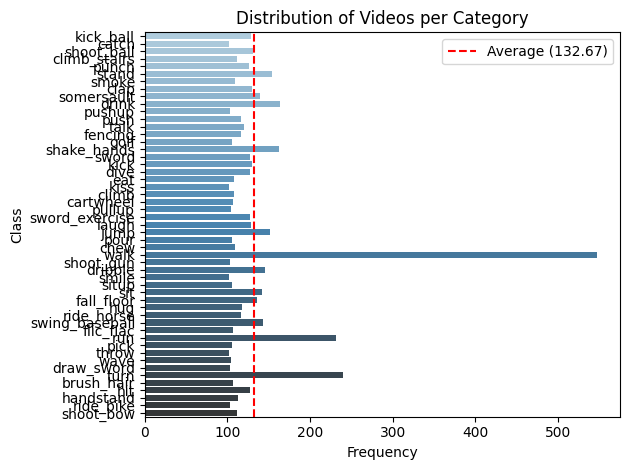

In [5]:
# Create a DataFrame for visualization
data = pd.DataFrame({
    "Class": all_classes_names,
    "Frequency": p
})

# Plot the distribution
sns.barplot(y="Class", x="Frequency", data=data, palette="Blues_d").set(title="Distribution of Videos per Category")
plt.axvline(x=avg, color='r', linestyle='--', label=f'Average ({avg:.2f})')
plt.legend()
plt.tight_layout()

# Save the plot (optional)
plt.savefig('/kaggle/working/category_distribution.eps', format='eps', dpi=1200, bbox_inches='tight')

# Show the plot
plt.show()


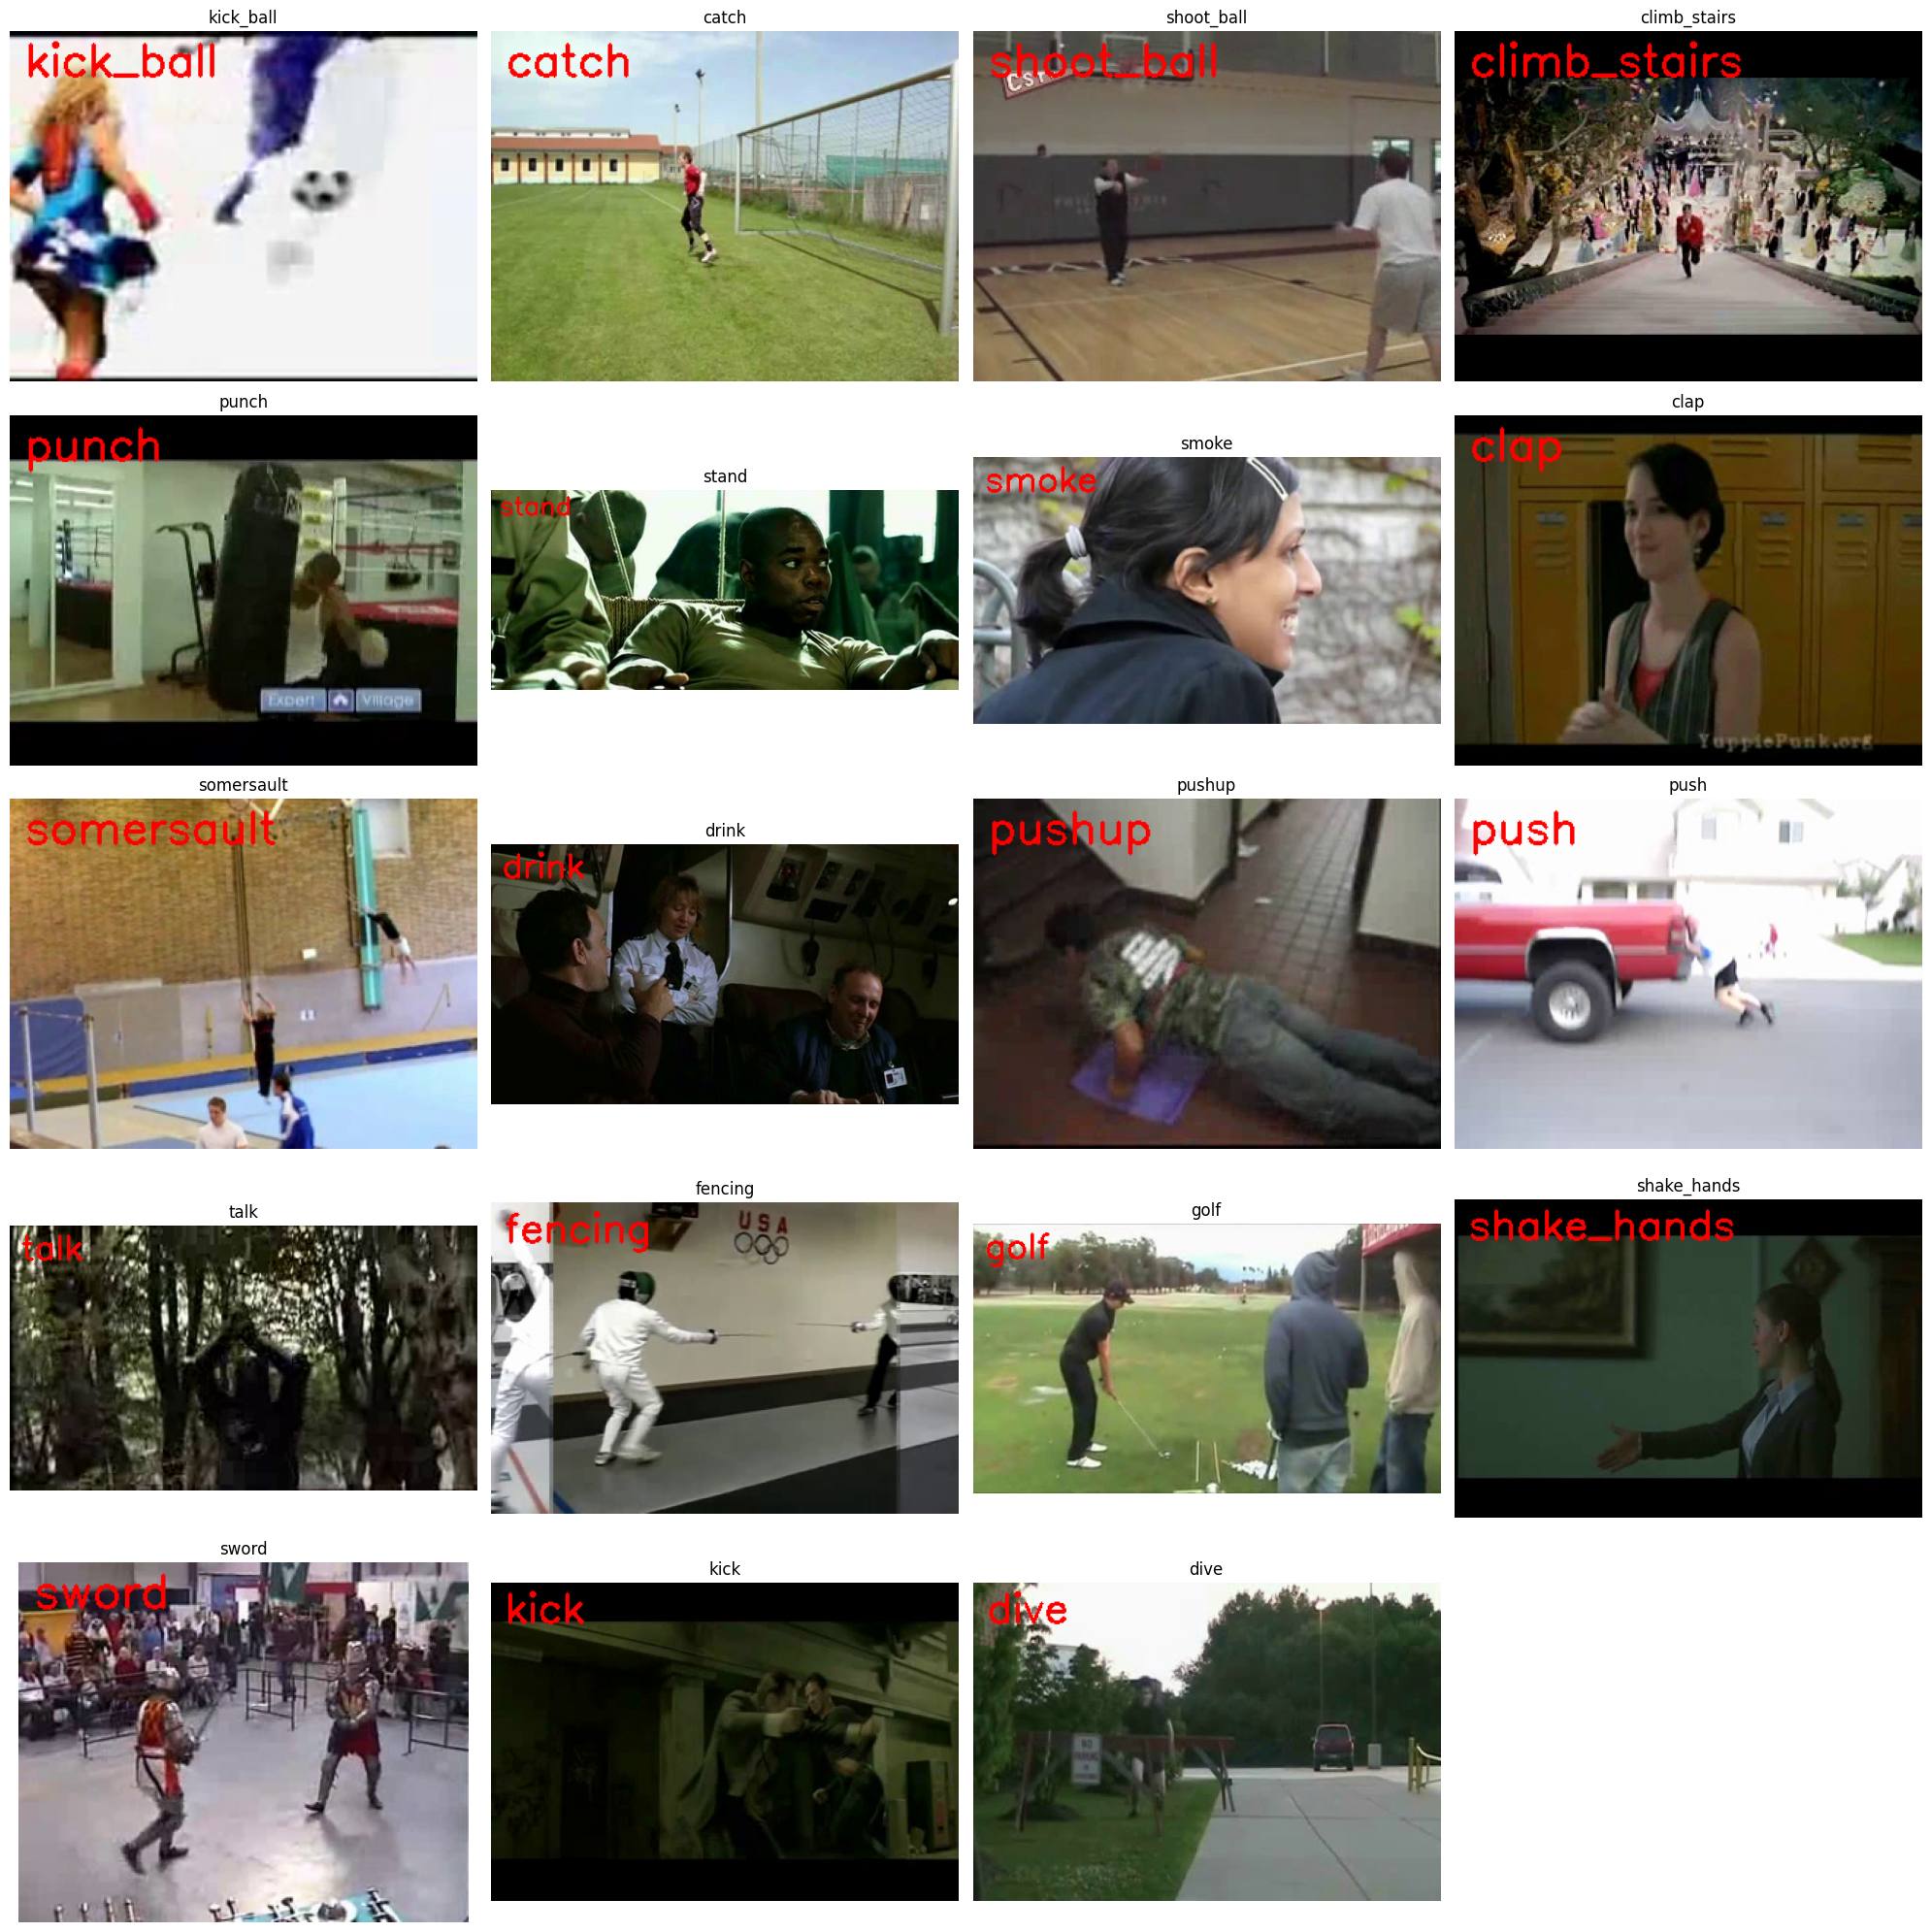

In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = '/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset'

# Get all category names
all_classes_names = os.listdir(dataset_path)

# Limit the number of categories to 19 or fewer (ensure it fits in a 5x4 grid)
max_categories = 19
selected_classes = all_classes_names[:max_categories]

# Define the figure size for displaying frames
plt.figure(figsize=(20, 20))

# Iterate through the selected categories
for counter, selected_class_Name in enumerate(selected_classes, start=1):
    # Get the list of all video files in the current category
    video_files_names_list = os.listdir(os.path.join(dataset_path, selected_class_Name))

    # Randomly select a video from the list
    selected_video_file_name = random.choice(video_files_names_list)

    # Read the selected video using OpenCV's VideoCapture
    video_path = os.path.join(dataset_path, selected_class_Name, selected_video_file_name)
    video_reader = cv2.VideoCapture(video_path)

    # Extract the first frame of the video
    success, bgr_frame = video_reader.read()
    video_reader.release()  # Release the video reader

    if success:
        # Convert the frame from BGR to RGB for proper color representation
        rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

        # Add the category name as text on the frame
        cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

        # Display the frame in a subplot
        plt.subplot(5, 4, counter)  # counter is managed by enumerate
        plt.imshow(rgb_frame)
        plt.axis('off')
        plt.title(selected_class_Name)

# Adjust the layout and display the figure
plt.tight_layout()
plt.show()


In [7]:
import cv2
import os
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# Constants
SEQUENCE_LENGTH = 7  # or whatever your sequence length is
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224  # resize dimensions for frames

# Function to extract frames from video
def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(video_frames_count / SEQUENCE_LENGTH), 1)

    for frame_counter in range(SEQUENCE_LENGTH):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0  # Normalize the frame
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

# Dataset class for video frames
class HumanActionDataset(Dataset):
    def __init__(self, imgs_path, transform=None):
        self.imgs_path = imgs_path
        self.transform = transform
        self.files_paths = [p for p in imgs_path.glob("**/*.mp4") if p.is_file()]  # Assuming .mp4 videos

    def __len__(self):
        return len(self.files_paths)

    def __getitem__(self, index):
        file_path = self.files_paths[index]
        frames = frames_extraction(file_path)

        # Convert frames to a tensor
        frames_tensor = np.stack(frames, axis=0)
        frames_tensor = torch.tensor(frames_tensor, dtype=torch.float32)

        # Apply any transformation if provided
        if self.transform:
            frames_tensor = self.transform(frames_tensor)

        label = file_path.parent.name
        label = class_to_idx[label]  # Assuming class_to_idx is defined elsewhere

        return frames_tensor, label


In [8]:
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import transforms
import numpy as np
import torch

# Function to get data loaders
def get_loaders(imgs_path, batch_size, val_split=0.1, shuffle=True, random_seed=42):
    # Define transformations for the video frames
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])

    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])
    
    # Create datasets for train, validation, and test sets
    train_dataset = HumanActionDataset(imgs_path / "train", transform=train_transform)
    val_dataset = HumanActionDataset(imgs_path / "train", transform=val_transform)
    test_dataset = HumanActionDataset(imgs_path / "test", transform=val_transform)

    # Split data into training and validation sets
    len_train = int(np.floor(len(train_dataset) * (1 - val_split)))
    len_val = len(train_dataset) - len_train

    indices = list(range(len(train_dataset)))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, val_idx = indices[:len_train], indices[len_train:]

    # Create samplers
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler = SubsetRandomSampler(val_idx)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, sampler=val_sampler)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader


Display images from the dataset

Create data loaders

In [9]:
from pathlib import Path

# Define dataset path
dataset_path = Path('/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset')

# Check if the dataset path exists
if dataset_path.exists():
    print(f"Dataset found: {dataset_path}")
    
    # Use glob to recursively find all .mp4 files inside subdirectories
    video_files = list(dataset_path.rglob("*.avi"))
    
    print(f"Found {len(video_files)} video files.")
    
    # Optionally, print the first few files for debugging
    print("Sample files found:")
    for file in video_files[:5]:  # Display first 5 files
        print(file)

else:
    print(f"Dataset path does not exist: {dataset_path}")


Dataset found: /kaggle/input/hmdb-human-activity-recognition/HMDB_dataset
Found 6766 video files.
Sample files found:
/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset/kick_ball/training_9.avi
/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset/kick_ball/training_73.avi
/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset/kick_ball/testing_20.avi
/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset/kick_ball/training_36.avi
/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset/kick_ball/training_40.avi


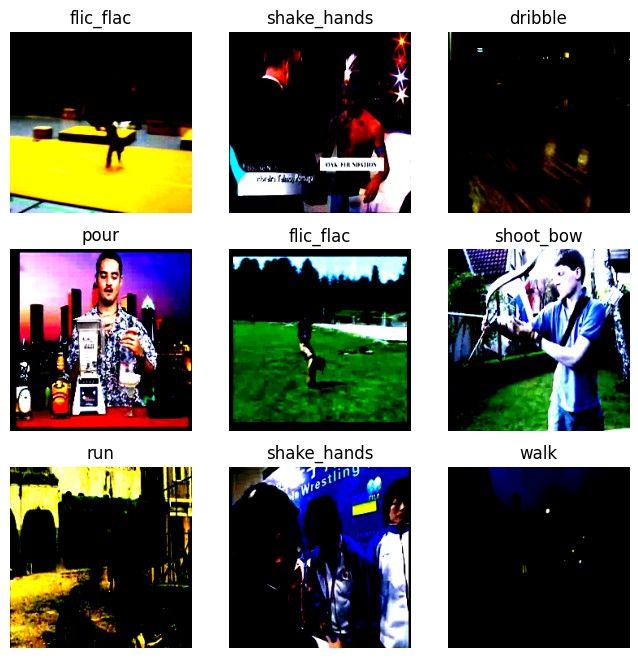

In [10]:
import torch
from torch.utils.data import Dataset
import cv2
import os
from pathlib import Path
from torchvision import transforms
import matplotlib.pyplot as plt

# Define your custom HumanActionDataset class
class HumanActionDataset(Dataset):
    def __init__(self, imgs_path, transform=None):
        """
        Custom dataset for human action recognition.
        :param imgs_path: Path to the dataset
        :param transform: Transformation to apply to images
        """
        self.imgs_path = imgs_path
        self.transform = transform
        self.class_names = sorted(os.listdir(imgs_path))  # Get class names (video categories)
        self.video_files = []  # List to store all video paths

        # Collect all video file paths
        for class_name in self.class_names:
            class_path = os.path.join(imgs_path, class_name)
            if os.path.isdir(class_path):
                video_paths = [os.path.join(class_path, video) for video in os.listdir(class_path) if video.endswith('.avi')]
                self.video_files.extend([(video, class_name) for video in video_paths])

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path, class_name = self.video_files[idx]
        cap = cv2.VideoCapture(video_path)
        
        # Read the first frame of the video
        ret, frame = cap.read()
        cap.release()

        if not ret:
            raise ValueError(f"Could not read frame from video: {video_path}")

        # Convert the frame to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if self.transform:
            frame = self.transform(frame)

        # Find the class index (label)
        label = self.class_names.index(class_name)
        
        return frame, label

# Example transformation
transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert from ndarray to PIL Image first
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Define the path to the dataset
dataset_path = Path('/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset')

# Initialize the HumanActionDataset
ds = HumanActionDataset(imgs_path=dataset_path, transform=transform)

# Define a mapping from label index to class name
idx_to_class = {i: class_name for i, class_name in enumerate(ds.class_names)}

# Plot random samples from the HumanActionDataset
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, rows * cols + 1):
    sample_idx = torch.randint(len(ds), size=(1,)).item()
    img, label = ds[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(idx_to_class[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))  # Convert from tensor format (C, H, W) to (H, W, C)

plt.show()


In [11]:
batch_size = 32

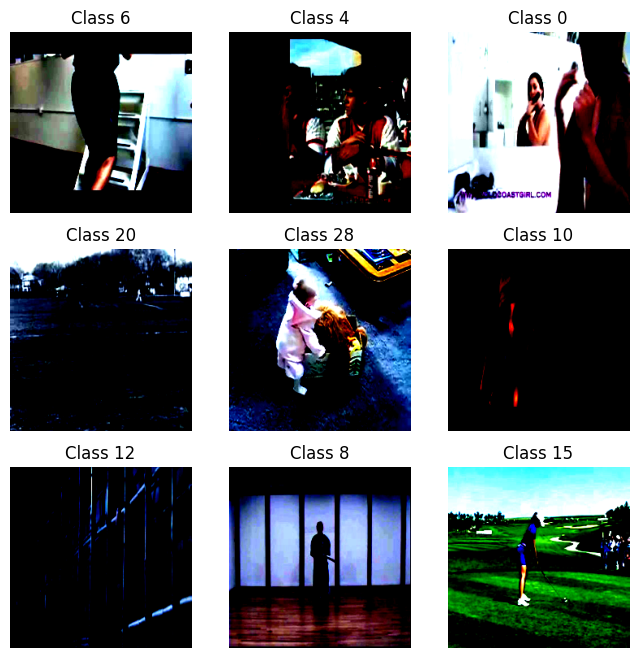

In [12]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from pathlib import Path
import os
import cv2
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

# Define the custom HumanActionDataset class (same as before)
class HumanActionDataset(Dataset):
    def __init__(self, imgs_path, transform=None):
        self.imgs_path = imgs_path
        self.transform = transform
        self.class_names = sorted(os.listdir(imgs_path))  # Get class names (video categories)
        self.video_files = []  # List to store all video paths

        # Collect all video file paths
        for class_name in self.class_names:
            class_path = os.path.join(imgs_path, class_name)
            if os.path.isdir(class_path):
                video_paths = [os.path.join(class_path, video) for video in os.listdir(class_path) if video.endswith('.avi')]
                self.video_files.extend([(video, class_name) for video in video_paths])

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path, class_name = self.video_files[idx]
        cap = cv2.VideoCapture(video_path)
        
        # Read the first frame of the video
        ret, frame = cap.read()
        cap.release()

        if not ret:
            raise ValueError(f"Could not read frame from video: {video_path}")

        # Convert the frame to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if self.transform:
            frame = self.transform(frame)

        # Find the class index (label)
        label = self.class_names.index(class_name)
        
        return frame, label


# Define the transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Dataset path
dataset_path = Path('/kaggle/input/hmdb-human-activity-recognition/HMDB_dataset')

# Initialize the dataset
dataset = HumanActionDataset(imgs_path=dataset_path, transform=transform)

# Function to split the dataset into train, val, and test loaders
def get_loaders(dataset, batch_size, val_split=0.1, test_split=0.1):
    # Get the total number of samples in the dataset
    total_size = len(dataset)
    
    # Calculate the size for train, validation, and test splits
    val_size = int(total_size * val_split)
    test_size = int(total_size * test_split)
    train_size = total_size - val_size - test_size

    # Split the dataset into train, validation, and test subsets
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

    # Create DataLoader for each subset
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


# Define batch size
batch_size = 16

# Get the data loaders
train_loader, val_loader, test_loader = get_loaders(dataset, batch_size)

# Example of how to use the data loaders (just displaying a few random samples from train_loader)
def show_samples(loader):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    for i in range(1, rows * cols + 1):
        img = images[i - 1]
        label = labels[i - 1]
        figure.add_subplot(rows, cols, i)
        plt.title(f"Class {label.item()}")
        plt.axis("off")
        plt.imshow(img.permute(1, 2, 0))  # Convert from tensor format (C, H, W) to (H, W, C)
    plt.show()

# Show random samples from the train_loader
show_samples(train_loader)


## Create Vision Transformer

In [13]:
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

class PreNorm(nn.Module):
    def __init__(self, dim, fn) -> None:
        super().__init__()

        self.ln = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.ln(x), **kwargs)

class FeedForward(nn.Module):
    def __init__(self, dim , hidden_dim, dropout=0) -> None:
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.) -> None:
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
    
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()


    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)
        out= torch.matmul(attn, v)

        out = rearrange(out, 'b h n d -> b n (h d)')

        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_heads, mlp_dim, dropout) -> None:
        super().__init__()

        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_heads, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, hidden_dim=mlp_dim, dropout=dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class ViT(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool='cls', channels=3, dim_heads=64, dropout=0., emb_dropout=0.) -> None:
        super().__init__()

        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'
    
        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width

        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_heads, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)
        
        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:,0]

        x = self.to_latent(x)

        return self.mlp_head(x) 

In [14]:
num_classes = len(dataset.class_names)

# Print the number of classes
print(f"Number of classes: {num_classes}")

Number of classes: 51


In [15]:
model = ViT(
    image_size=224,
    patch_size=32,
    num_classes=num_classes,
    dim=768,
    depth=12,
    heads=12,
    mlp_dim=3072,
)

In [16]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
ViT                                                [1, 51]                   39,168
├─Sequential: 1-1                                  [1, 49, 768]              --
│    └─Rearrange: 2-1                              [1, 49, 3072]             --
│    └─Linear: 2-2                                 [1, 49, 768]              2,360,064
├─Dropout: 1-2                                     [1, 50, 768]              --
├─Transformer: 1-3                                 [1, 50, 768]              --
│    └─ModuleList: 2-3                             --                        --
│    │    └─ModuleList: 3-1                        --                        7,085,568
│    │    └─ModuleList: 3-2                        --                        7,085,568
│    │    └─ModuleList: 3-3                        --                        7,085,568
│    │    └─ModuleList: 3-4                        --                        7,085,

## Train model

In [17]:
total_steps = len(train_loader)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torchvision import transforms

# Hyperparameters
num_epochs = 100
learning_rate = 0.0001  # Lower learning rate for fine-tuning
weight_decay_rate = 0.0001  # Lower weight decay to prevent over-regularization
momentum = 0.9
batch_size = 64  # Larger batch size for stable gradients

# Criterion and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

# Learning rate scheduler (StepLR to decay the learning rate every 20 epochs)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Define path to save checkpoints
checkpoint_dir = '/kaggle/working/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Function to save the checkpoint
def save_checkpoint(epoch, model, optimizer, loss, accuracy, filename="checkpoint.pth.tar"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'accuracy': accuracy
    }
    checkpoint_path = os.path.join(checkpoint_dir, filename)
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved to {checkpoint_path}")

# Data Augmentation (if not already done, here is an example)
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(20),  # Randomly rotate images by 20 degrees
    transforms.Resize((224, 224)),  # Resize to a standard input size
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])



# Training loop with checkpointing
best_acc = 0.0  # Track best validation accuracy
early_stopping_patience = 5  # Number of epochs to wait before stopping if no improvement
patience_counter = 0  # Counter for early stopping

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    # Training step
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update model parameters

        running_loss += loss.item()

    # Print epoch loss
    print(f"Epoch [{epoch+1}/{num_epochs}], loss: {running_loss / total_steps:.4f}")
    
    # Validation step
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # Forward pass
            _, preds = torch.max(outputs.data, 1)  # Get predicted labels

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"Validation accuracy: {acc:.2f}%")
    
    # Check if validation accuracy improved
    if (epoch + 1) % 20 == 0:
        if acc > best_acc:
            print("Validation accuracy improved, saving checkpoint...")
            best_acc = acc
            save_checkpoint(epoch, model, optimizer, loss.item(), acc, filename="best_model.pth.tar")
            patience_counter = 0  # Reset patience if accuracy improved
        else:
            patience_counter += 1

    # Save checkpoint at the end of each epoch
    #save_checkpoint(epoch, model, optimizer, loss.item(), acc, filename=f"epoch_{epoch+1}_checkpoint.pth.tar")

    # Early stopping
    if patience_counter >= early_stopping_patience:
        print("Early stopping triggered. Stopping training.")
        break

    # Step the learning rate scheduler
    scheduler.step()

print("Training completed.")


Epoch [1/100], loss: 3.3389
Validation accuracy: 13.61%
Epoch [2/100], loss: 3.0864
Validation accuracy: 18.34%
Epoch [3/100], loss: 2.8559
Validation accuracy: 21.15%
Epoch [4/100], loss: 2.5888
Validation accuracy: 23.52%
Epoch [5/100], loss: 2.2967
Validation accuracy: 25.00%
Epoch [6/100], loss: 1.9781
Validation accuracy: 28.55%
Epoch [7/100], loss: 1.6551
Validation accuracy: 28.11%
Epoch [8/100], loss: 1.3427
Validation accuracy: 30.03%
Epoch [9/100], loss: 1.0230
Validation accuracy: 29.73%
Epoch [10/100], loss: 0.7908
Validation accuracy: 30.33%
Epoch [11/100], loss: 0.6239
Validation accuracy: 32.25%
Epoch [12/100], loss: 0.4521
Validation accuracy: 29.88%
Epoch [13/100], loss: 0.3389
Validation accuracy: 28.40%
Epoch [14/100], loss: 0.2790
Validation accuracy: 28.70%
Epoch [15/100], loss: 0.3658
Validation accuracy: 29.29%
Epoch [16/100], loss: 0.3291
Validation accuracy: 31.36%
Epoch [17/100], loss: 0.1937
Validation accuracy: 30.47%
Epoch [18/100], loss: 0.1374
Validation 

In [ ]:
# Example to load a checkpoint (e.g., after resuming training)
checkpoint_path = '/kaggle/working/checkpoints/best_model.pth.tar'
checkpoint = torch.load(checkpoint_path)

# Load the model and optimizer state
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Resume from the saved epoch and accuracy
epoch = checkpoint['epoch']
best_acc = checkpoint['accuracy']

print(f"Resumed from epoch {epoch}, with best accuracy of {best_acc:.2f}%")


In [ ]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        del images, labels, outputs

    print(f'Test accuracy: {100 * correct / total:.2f} %')